<div style="background-color: #0596A6; padding: 20px; width: 100%; text-align: center;">

  <div style="max-width: 100%; width: 100%; margin: auto;">
    <svg width="100%" height="100" xmlns="http://www.w3.org/2000/svg">
      <rect width="100%" height="100" fill="#0596A6"/>
      <text x="50%" y="50%" dominant-baseline="middle" text-anchor="middle" font-size="40" fill="#FFFFFF" font-family="Arial, sans-serif">
        Big Data Management for Data Science
      </text>
    </svg>
  </div>

  <h1 style="color: #FFFFFF;"><b>Lab 1 - Graph Databases</b></h1>

  <h3 style="color: #FFFFFF;"> Team 1: Aleksandr Smolin · Julian Romero </h3>

  <h4 style="color: #FFFFFF;">April, 2025</h4>

  <hr style="width: max-width; margin: 20px auto;">

</div>


In [64]:
import polars as pl
import random
from datetime import datetime, timedelta


pl.Config.set_tbl_cols(-1) 

polars.config.Config

In [65]:
DATA = '../data/files'
MISSING_THRESHOLD = 0.5
NUMBER_OF_JOURNALS = 250*1000
NUMBER_OF_CONFERENCES = 750*1000

# A.1.
---

This section is in the Lab Document.

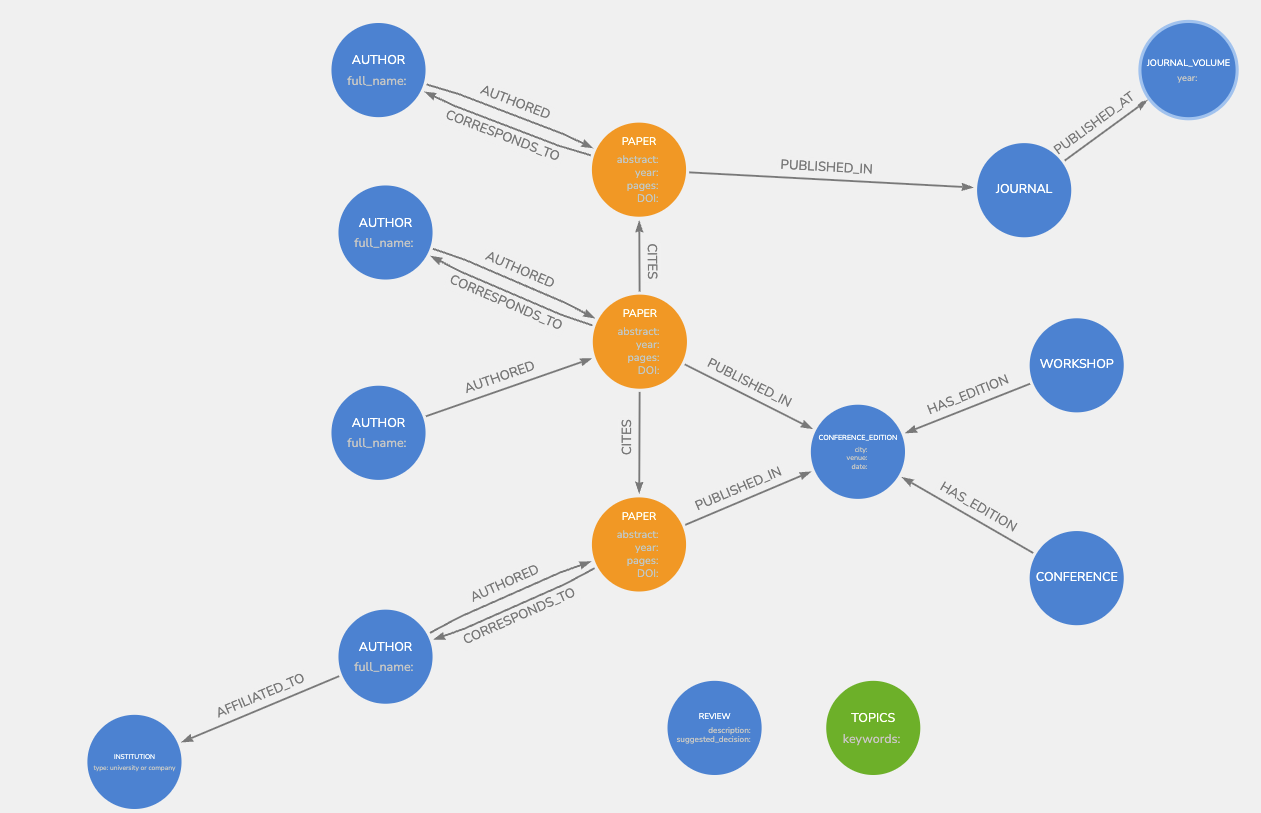

# A.2.
---

## Understaing the DBLP data

| File | What It Contains | Example |
|:-----|:-----------------|:--------|
| **article** | Scientific articles published in **journals**. | A research paper in *Nature* or *JMLR* (Journal of Machine Learning Research). |
| **author** | Information about **authors**: names, aliases, maybe IDs. | "Yoshua Bengio", "Geoffrey Hinton". |
| **inproceedings** | A **paper** presented at a **conference** and included in the **proceedings**. | A NeurIPS paper like *"Transformers"*. |
| **journal** | Metadata about **journals** themselves. | *Journal of Machine Learning Research*, *Nature*, etc. |
| **journal_published_in** | Relationship: which **article** was published in which **journal**. | Links an article to *Nature* |
| **proceedings** | Metadata about **conference proceedings volumes** (like a "book" of all accepted papers). | *Proceedings of NeurIPS 2024*. |


From this data, we will only care about articles, author, inproceedings, jounral, journal_published_in, and proceedings

## Functions

In [66]:
def drop_many_nulls(df: pl.DataFrame, threshold: float = 0.5) -> pl.DataFrame:
    return df.select(
        [col for col in df.columns if (df.null_count().select(pl.col(col)).item() / df.height) <= threshold]
    )

def schema_type(columns: list[str]) -> dict[str, pl.DataType]:
    data_types = {
        'ID': pl.Int32,
        'int': pl.Int32,
        'string': pl.Utf8,
        'string[]': pl.List(pl.Utf8),
        'float': pl.Float32,
        'str': pl.Utf8,
        'bool': pl.Boolean,
        'date': pl.Date,
    }
    return {col: data_types[col.split(':')[-1]] for col in columns}

countries   = ["United States","United Kingdom","Canada","Australia",
               "Germany","France","Spain","Italy","Netherlands","Sweden"]
def random_date(start_year=1950, end_year=1995):
    start = datetime(start_year, 1, 1)
    end   = datetime(end_year, 12, 31)
    delta = end - start
    return (start + timedelta(days=random.randrange(delta.days))).date()


## Raw data loading and inspection

### Authors

In [67]:
df_aut = pl.read_csv(
        f'{DATA}/dblp_author.csv',
        ignore_errors=True,
        separator=';',
    )
df_aut = (df_aut
        .pipe(drop_many_nulls, threshold=MISSING_THRESHOLD)
        .unique(subset=[":ID"])
        .rename({"author:string": "name:string"})
    )
print(df_aut.shape)
print(df_aut.head())

(3861533, 2)
shape: (5, 2)
┌──────────┬─────────────────────────┐
│ :ID      ┆ name:string             │
│ ---      ┆ ---                     │
│ i64      ┆ str                     │
╞══════════╪═════════════════════════╡
│ 11632574 ┆ Ahmed J. Khan           │
│ 12803234 ┆ Kalaivany Ganesh        │
│ 14916256 ┆ Rares Anthony Vacarescu │
│ 11979943 ┆ Siriporn Pattamaset     │
│ 15275558 ┆ Tony Sparrow            │
└──────────┴─────────────────────────┘


### Conference Edition (proceedings)

In [68]:
col_names = pl.read_csv(f'{DATA}/dblp_proceedings_header.csv',separator=';').columns

df_conf_edition = pl.read_csv(
        f'{DATA}/dblp_proceedings.csv',
        ignore_errors=True,
        separator=';',
        new_columns=col_names,
    )

df_conf_edition = (
    df_conf_edition
    .pipe(drop_many_nulls, threshold=MISSING_THRESHOLD)
    .rename({"editor:string[]": "author:string[]",
             "proceedings:ID": ":ID",})
    .with_columns(
                pl.when(pl.col("title:string").str.to_lowercase().str.contains("workshop"))
                .then(pl.lit("workshop"))
                .otherwise(pl.lit("conference"))
                .alias("conf_type"),
                pl.col("author:string[]").str.split("|")
                ).explode("author:string[]")
    .join(
        df_aut,
        left_on="author:string[]",
        right_on="name:string",
        how="left",
    )

)  

print(df_conf_edition.shape)
print(df_conf_edition.head())

(166542, 13)
shape: (5, 13)
┌─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ :ID ┆ boo ┆ aut ┆ ee:str ┆ isbn: ┆ key:s ┆ mdate ┆ publi ┆ title ┆ url:s ┆ year: ┆ conf_ ┆ :ID_r │
│ --- ┆ kti ┆ hor ┆ ing[]  ┆ strin ┆ tring ┆ :date ┆ sher: ┆ :stri ┆ tring ┆ int   ┆ type  ┆ ight  │
│ i64 ┆ tle ┆ :st ┆ ---    ┆ g[]   ┆ ---   ┆ ---   ┆ strin ┆ ng    ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│     ┆ :st ┆ rin ┆ str    ┆ ---   ┆ str   ┆ str   ┆ g[]   ┆ ---   ┆ str   ┆ i64   ┆ str   ┆ i64   │
│     ┆ rin ┆ g[] ┆        ┆ str   ┆       ┆       ┆ ---   ┆ str   ┆       ┆       ┆       ┆       │
│     ┆ g   ┆ --- ┆        ┆       ┆       ┆       ┆ str   ┆       ┆       ┆       ┆       ┆       │
│     ┆ --- ┆ str ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│     ┆ str ┆     ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
╞═════╪═════╪═════╪════════╪═══════╪═══════╪═══════╪═══════╪═══

In [69]:
df_conf_edition.head()

:ID,booktitle:string,author:string[],ee:string[],isbn:string[],key:string,mdate:date,publisher:string[],title:string,url:string,year:int,conf_type,:ID_right
i64,str,str,str,str,str,str,str,str,str,i64,str,i64
27960,null,"""Amir Hossein Alavi""","""https://doi.org/10.1007/978-3-…","""978-3-319-20882-4""","""reference/genetic/2015""","""2020-03-27""","""Springer""","""Handbook of Genetic Programmin…","""db/reference/genetic/genetic20…",2015,"""conference""",11604107
27960,null,"""Amir Hossein Gandomi""","""https://doi.org/10.1007/978-3-…","""978-3-319-20882-4""","""reference/genetic/2015""","""2020-03-27""","""Springer""","""Handbook of Genetic Programmin…","""db/reference/genetic/genetic20…",2015,"""conference""",11604108
27960,null,"""Conor Ryan""","""https://doi.org/10.1007/978-3-…","""978-3-319-20882-4""","""reference/genetic/2015""","""2020-03-27""","""Springer""","""Handbook of Genetic Programmin…","""db/reference/genetic/genetic20…",2015,"""conference""",11578328
32826,null,"""Aaron K. Baughman""","""https://doi.org/10.1007/978-3-…","""978-3-319-14997-4""","""books/sp/BGPP2015""","""2017-05-16""","""Springer""","""Multimedia Data Mining and Ana…","""db/books/collections/BGPP2015.…",2015,"""conference""",11602106
32826,null,"""Jia-Yu Pan""","""https://doi.org/10.1007/978-3-…","""978-3-319-14997-4""","""books/sp/BGPP2015""","""2017-05-16""","""Springer""","""Multimedia Data Mining and Ana…","""db/books/collections/BGPP2015.…",2015,"""conference""",11602116


In [70]:
df_conf_edition.lazy().select(
    pl.col("conf_type").value_counts()
).collect()


conf_type
struct[2]
"{""workshop"",46106}"
"{""conference"",120436}"


In [71]:
df_conf_edition.select(
    pl.col(":ID").n_unique()
).item()


61422

### Workshops and Conferences (inproceedings)

In [72]:
col_names = pl.read_csv(f'{DATA}/dblp_inproceedings_header.csv',separator=';').columns

df_work_conf = pl.read_csv(
        f'{DATA}/dblp_inproceedings.csv',
        ignore_errors=True,
        separator=';',
        new_columns=col_names,
    ).sample(n=NUMBER_OF_CONFERENCES, seed=42)
df_work_conf = (
    df_work_conf
    .pipe(drop_many_nulls, threshold=MISSING_THRESHOLD)
    .rename({'inproceedings:ID': ':ID',})
    .filter(pl.col("author:string[]").is_not_null(),
            pl.col("title:string").is_not_null(),
    )
)  

print(df_work_conf.shape)
print(df_work_conf.head())

(748687, 11)
shape: (5, 11)
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ :ID    ┆ author ┆ bookti ┆ crossr ┆ ee:str ┆ key:st ┆ mdate: ┆ pages: ┆ title: ┆ url:st ┆ year:i │
│ ---    ┆ :strin ┆ tle:st ┆ ef:str ┆ ing[]  ┆ ring   ┆ date   ┆ string ┆ string ┆ ring   ┆ nt     │
│ i64    ┆ g[]    ┆ ring   ┆ ing[]  ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│        ┆ ---    ┆ ---    ┆ ---    ┆ str    ┆ str    ┆ str    ┆ str    ┆ str    ┆ str    ┆ i64    │
│        ┆ str    ┆ str    ┆ str    ┆        ┆        ┆        ┆        ┆        ┆        ┆        │
╞════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 825169 ┆ Anurag ┆ USENIX ┆ conf/u ┆ https: ┆ conf/u ┆ 2021-0 ┆ 2451-2 ┆ Pancak ┆ db/con ┆ 2020   │
│ 6      ┆ Khande ┆ Securi ┆ ss/202 ┆ //www. ┆ ss/Gru ┆ 1-29   ┆ 468    ┆ e: Fre ┆ f/uss/ ┆        │
│        ┆ lwal|L ┆ ty Sym ┆ 0      ┆ usenix ┆ bbsKLB ┆        

In [73]:
print('Percentages of missing by column', df_work_conf.null_count() / df_work_conf.shape[0] * 100)

Percentages of missing by column shape: (1, 11)
┌─────┬─────────┬─────────┬─────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ :ID ┆ author: ┆ booktit ┆ crossre ┆ ee:str ┆ key:st ┆ mdate: ┆ pages: ┆ title: ┆ url:st ┆ year:i │
│ --- ┆ string[ ┆ le:stri ┆ f:strin ┆ ing[]  ┆ ring   ┆ date   ┆ string ┆ string ┆ ring   ┆ nt     │
│ f64 ┆ ]       ┆ ng      ┆ g[]     ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---    │
│     ┆ ---     ┆ ---     ┆ ---     ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64    │
│     ┆ f64     ┆ f64     ┆ f64     ┆        ┆        ┆        ┆        ┆        ┆        ┆        │
╞═════╪═════════╪═════════╪═════════╪════════╪════════╪════════╪════════╪════════╪════════╪════════╡
│ 0.0 ┆ 0.0     ┆ 0.0     ┆ 0.07239 ┆ 3.7384 ┆ 0.0    ┆ 0.0    ┆ 5.3734 ┆ 0.0    ┆ 0.0    ┆ 0.0    │
│     ┆         ┆         ┆ 3       ┆ 11     ┆        ┆        ┆ 07     ┆        ┆        ┆        │
└─────┴─────────┴─────────┴─────────┴──────

### Journal (DELETE)

In [74]:
# df_journ = pl.read_csv(
#         f'{DATA}/dblp_journal.csv',
#         ignore_errors=True,
#         separator=';',
#     )
# df_journ = (
#     df_journ
#     .pipe(drop_many_nulls, threshold=MISSING_THRESHOLD)

# )  

# print(df_journ.shape)
# print(df_journ.head())

In [75]:
# df_journ_pub = pl.read_csv(
#         f'{DATA}/dblp_journal_published_in.csv',
#         ignore_errors=True,
#         separator=';',
#         # new_columns=col_names,
#     )
# df_journ_pub = (
#     df_journ_pub
#     .pipe(drop_many_nulls, threshold=MISSING_THRESHOLD)

# )  

# print(df_journ_pub.shape)
# print(df_journ_pub.head())

### Journals

In [76]:
col_names = pl.read_csv(f'{DATA}/dblp_article_header.csv',separator=';').columns
df_jour = (pl.read_csv(
        f'{DATA}/dblp_article.csv',
        ignore_errors=True,
        separator=';',
        new_columns=col_names,
    )
    .sample(n=NUMBER_OF_JOURNALS, seed=42)
)
df_jour = (df_jour
          .pipe(drop_many_nulls, threshold=MISSING_THRESHOLD)
          .filter(pl.col("author:string[]").is_not_null())
          .filter(pl.col("title:string").is_not_null())
          .rename({"article:ID": ":ID",})
          .filter(pl.col("author:string[]").is_not_null())
        #   .with_columns(
        #         pl.col("author:string[]").str.split("|")
        #         ).explode("author:string[]")
        # .join(
        #     df_aut,
        #     left_on="author:string[]",
        #     right_on="name:string",
        #     how="left",
        # )
        .with_columns(
                    pl.col("url:string[]").str.split("|").list.get(0).alias("url:string")
        )
          )
print("Journals shape",df_jour.shape)
df_jour.head(5)

Journals shape (248068, 13)


:ID,author:string[],ee:string[],journal:string,key:string,mdate:date,number:string,pages:string,title:string,url:string[],volume:string,year:int,url:string
i64,str,str,str,str,str,str,str,str,str,i64,i64,str
682555,"""Enguday Ademe Mekonnen|Ermias …","""https://doi.org/10.1080/089934…","""Comput. Sci. Educ.""","""journals/csedu/KassaM22""","""2023-01-31""","""4""","""502-531""","""Computational thinking in the …","""db/journals/csedu/csedu32.html…",32,2022,"""db/journals/csedu/csedu32.html…"
1237689,"""Hideaki Sugawara|Satoru Miyaza…","""https://doi.org/10.1093/nar/gk…","""Nucleic Acids Res.""","""journals/nar/SugawaraM03a""","""2020-05-17""","""13""","""3836-3839""","""Biological SOAP servers and we…","""db/journals/nar/nar31.html#Sug…",31,2003,"""db/journals/nar/nar31.html#Sug…"
1204447,"""Junxia Xiong|Liang Zhao|Ling W…","""https://doi.org/10.1111/jcal.1…","""J. Comput. Assist. Learn.""","""journals/jcal/DaiWPZX24""","""2025-01-08""","""6""","""2901-2916""","""A model for assessing student …","""db/journals/jcal/jcal40.html#D…",40,2024,"""db/journals/jcal/jcal40.html#D…"
2873202,"""Bahana Wiradanti|Rajesri Govin…","""https://doi.org/10.1504/IJBIS.…","""Int. J. Bus. Inf. Syst.""","""journals/ijbis/GovindarajuW15""","""2020-04-25""","""3""","""279-299""","""Factors influencing the willin…","""db/journals/ijbis/ijbis19.html…",19,2015,"""db/journals/ijbis/ijbis19.html…"
2140197,"""Emmanuel Vincent 0001|Nicolas …","""https://arxiv.org/abs/2002.016…","""CoRR""","""journals/corr/abs-2002-01687""","""2020-09-18""",null,null,"""Limitations of weak labels for…","""db/journals/corr/corr2002.html…",null,2020,"""db/journals/corr/corr2002.html…"


In [77]:
print('Percentages of missing by column', df_jour.null_count() / df_jour.shape[0] * 100)

Percentages of missing by column shape: (1, 13)
┌─────┬─────┬─────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ :ID ┆ aut ┆ ee: ┆ journa ┆ key:s ┆ mdate ┆ numbe ┆ pages ┆ title ┆ url:s ┆ volum ┆ year: ┆ url:s │
│ --- ┆ hor ┆ str ┆ l:stri ┆ tring ┆ :date ┆ r:str ┆ :stri ┆ :stri ┆ tring ┆ e:str ┆ int   ┆ tring │
│ f64 ┆ :st ┆ ing ┆ ng     ┆ ---   ┆ ---   ┆ ing   ┆ ng    ┆ ng    ┆ []    ┆ ing   ┆ ---   ┆ ---   │
│     ┆ rin ┆ []  ┆ ---    ┆ f64   ┆ f64   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ f64   ┆ f64   │
│     ┆ g[] ┆ --- ┆ f64    ┆       ┆       ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆       ┆       │
│     ┆ --- ┆ f64 ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│     ┆ f64 ┆     ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
╞═════╪═════╪═════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
│ 0.0 ┆ 0.0 ┆ 0.5 ┆ 0.0    ┆ 0.0   ┆ 0.0   

## Final Data

### Author

In [78]:
df_node_author = (
    pl.concat([
        df_work_conf.select(['author:string[]']),
        df_jour.select(['author:string[]']),
    ])
    .with_columns(
        pl.col("author:string[]").str.split("|"),
    )
    .explode("author:string[]") #to have one author per row
    .rename({"author:string[]":"name:string"})
    .unique()
    .join(
        df_aut,
        left_on="name:string",
        right_on="name:string",
        how="left",
    )
    .select([":ID", "name:string"])
)
df_node_author = (
    df_node_author
    .with_columns([
        pl.Series([random.choice(countries) for _ in range(df_node_author.height)]).alias("country_of_birth:string"),
        pl.Series([random_date().isoformat() for _ in range(df_node_author.height)]).alias("date_of_birth:date"),
        pl.Series([random.choice([True, False]) for _ in range(df_node_author.height)]).alias("is_phd:bool")
    ])
    .pipe(lambda df_: df_.cast(schema_type(df_.columns))) #cast to correct data types
)

df_node_author

:ID,name:string,country_of_birth:string,date_of_birth:date,is_phd:bool
i32,str,str,date,bool
11571312,"""Michael Gelfond""","""Netherlands""",1976-10-07,true
15211866,"""Jeng-Kuen Chiu""","""United Kingdom""",1979-10-21,true
11614749,"""Jovanka Adzic""","""United States""",1960-01-13,true
12004207,"""Deris Stiawan""","""Australia""",1986-11-19,true
12816521,"""Kenzo Kojima""","""United Kingdom""",1979-07-16,false
…,…,…,…,…
12422816,"""Sabrina Salberg""","""Germany""",1985-04-17,false
12673507,"""Xingqi Cui""","""Germany""",1950-03-06,false
13277934,"""Yoàv Montacute""","""Italy""",1991-10-19,false


In [79]:
print('Percentages of missing by column', df_node_author.null_count() / df_node_author.shape[0] * 100)

Percentages of missing by column shape: (1, 5)
┌─────┬─────────────┬─────────────────────────┬────────────────────┬─────────────┐
│ :ID ┆ name:string ┆ country_of_birth:string ┆ date_of_birth:date ┆ is_phd:bool │
│ --- ┆ ---         ┆ ---                     ┆ ---                ┆ ---         │
│ f64 ┆ f64         ┆ f64                     ┆ f64                ┆ f64         │
╞═════╪═════════════╪═════════════════════════╪════════════════════╪═════════════╡
│ 0.0 ┆ 0.0         ┆ 0.0                     ┆ 0.0                ┆ 0.0         │
└─────┴─────────────┴─────────────────────────┴────────────────────┴─────────────┘


### Paper

In [82]:
papers_cols = [":ID", "title:string", "year:int", "pages:string", "url:string", 
               "ee:string[]","key:string"]
df_node_paper = (
    pl.concat([
        df_work_conf.select(papers_cols),
        df_jour.select(papers_cols),
    ])
    .unique(subset=[":ID"])
    .with_columns(
                pl.col("ee:string[]").str.split("|").list.get(0).alias("DOI:string"),
                pl.lit("Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod",
                ).alias("abstract:string"),
    )
    .drop("ee:string[]")
    .fill_null("unknown")
    .pipe(lambda df_: df_.cast(schema_type(df_.columns)))
    
)

df_node_paper

:ID,title:string,year:int,pages:string,url:string,key:string,DOI:string,abstract:string
i32,str,i32,str,str,str,str,str
7881732,"""Protect Sensitive Information …",2017,"""203-210""","""db/conf/cse/cse2017-2.html#Zha…","""conf/cse/ZhangTLCGFW17""","""https://doi.ieeecomputersociet…","""Lorem ipsum dolor sit amet, co…"
9087527,"""Bacterial foraging oriented by…",2009,"""445-450""","""db/conf/cira/cira2009.html#Kor…","""conf/cira/KoraniDE09""","""https://doi.org/10.1109/CIRA.2…","""Lorem ipsum dolor sit amet, co…"
1588168,"""Imaging of the Finger Vein and…",2017,"""925""","""db/journals/sensors/sensors17.…","""journals/sensors/LeeMLGKCL17""","""https://doi.org/10.3390/s17040…","""Lorem ipsum dolor sit amet, co…"
231898,"""Weighted Adversarial Domain Ad…",2022,"""1-11""","""db/journals/tim/tim71.html#Wu0…","""journals/tim/Wu0Z0S22""","""https://doi.org/10.1109/TIM.20…","""Lorem ipsum dolor sit amet, co…"
10941379,"""Turning Mass Media to Your Med…",2005,"""887-893""","""db/conf/kes/kes2005-2.html#Lai…","""conf/kes/LaiS05""","""https://doi.org/10.1007/115524…","""Lorem ipsum dolor sit amet, co…"
…,…,…,…,…,…,…,…
11147535,"""Force Amplitude Perception in …",2008,"""121-127""","""db/conf/haptics/haptics2008.ht…","""conf/haptics/DorjgotovBAPD08""","""https://doi.ieeecomputersociet…","""Lorem ipsum dolor sit amet, co…"
3485938,"""Geometric Optimum Experimental…",2014,"""346-359""","""db/journals/tcsv/tcsv24.html#Z…","""journals/tcsv/ZhangWLY14""","""https://doi.org/10.1109/TCSVT.…","""Lorem ipsum dolor sit amet, co…"
11212428,"""Data Quality Model-based Testi…",2020,"""1-8""","""db/conf/iotsms/iotsms2020.html…","""conf/iotsms/NikiforovaBBO20""","""https://doi.org/10.1109/IOTSMS…","""Lorem ipsum dolor sit amet, co…"


In [83]:
print('Percentages of missing by column', df_node_paper.null_count() / df_node_paper.shape[0] * 100)

Percentages of missing by column shape: (1, 8)
┌─────┬──────────────┬──────────┬─────────────┬────────────┬────────────┬────────────┬─────────────┐
│ :ID ┆ title:string ┆ year:int ┆ pages:strin ┆ url:string ┆ key:string ┆ DOI:string ┆ abstract:st │
│ --- ┆ ---          ┆ ---      ┆ g           ┆ ---        ┆ ---        ┆ ---        ┆ ring        │
│ f64 ┆ f64          ┆ f64      ┆ ---         ┆ f64        ┆ f64        ┆ f64        ┆ ---         │
│     ┆              ┆          ┆ f64         ┆            ┆            ┆            ┆ f64         │
╞═════╪══════════════╪══════════╪═════════════╪════════════╪════════════╪════════════╪═════════════╡
│ 0.0 ┆ 0.0          ┆ 0.0      ┆ 0.0         ┆ 0.0        ┆ 0.0        ┆ 0.0        ┆ 0.0         │
└─────┴──────────────┴──────────┴─────────────┴────────────┴────────────┴────────────┴─────────────┘


### Keywords

In [76]:
# Predefined keywords
keywords = [
    "Graph Processing", "Data Quality", "Property Graph", "Machine Learning", "Big Data",
    "Data Mining", "Distributed Systems", "Knowledge Graph", "Semantic Web", "Data Integration",
    "Stream Processing", "Graph Databases", "Query Optimization", "Parallel Computing",
    "Data Visualization", "Graph Algorithms", "Data Cleaning", "Network Analysis",
    "Ontologies", "Metadata Management"
]

# Assign a unique ID to each keyword
keyword_to_id = {kw: f"kw_{i+1}" for i, kw in enumerate(keywords)}

df_keyword = pl.DataFrame({
            ":ID": list(keyword_to_id.values()),
            "name:string": list(keyword_to_id.keys()),
        })

# Create the dataframe
df_edge_has_keyword = (
    df_papers
    .with_columns(
        pl.Series(
            "keywords", 
            [random.sample(keywords, random.randint(1, 3)) for _ in range(df_papers.height)]
        )
    )
    .explode("keywords") #to have one keyword per row
    .with_columns(
        pl.col("keywords").alias("keyword:string"),
        pl.col(":ID").alias("paper_id:ID"),
        pl.col("keywords").replace_strict(keyword_to_id).alias("keyword_id:ID")
    )
    .select(
        "paper_id:ID",
        "keyword_id:ID"
    )
    .rename({"paper_id:ID":":START_ID", 
             "keyword_id:ID":":END_ID"})

)
print("Keywords dataframe shape:", df_keyword.shape)
print(df_keyword.head(10))
print("Edge dataframe shape:", df_edge_has_keyword.shape)
print(df_edge_has_keyword.head(10))


Keywords dataframe shape: (20, 2)
shape: (10, 2)
┌───────┬─────────────────────┐
│ :ID   ┆ name:string         │
│ ---   ┆ ---                 │
│ str   ┆ str                 │
╞═══════╪═════════════════════╡
│ kw_1  ┆ Graph Processing    │
│ kw_2  ┆ Data Quality        │
│ kw_3  ┆ Property Graph      │
│ kw_4  ┆ Machine Learning    │
│ kw_5  ┆ Big Data            │
│ kw_6  ┆ Data Mining         │
│ kw_7  ┆ Distributed Systems │
│ kw_8  ┆ Knowledge Graph     │
│ kw_9  ┆ Semantic Web        │
│ kw_10 ┆ Data Integration    │
└───────┴─────────────────────┘
Edge dataframe shape: (7721452, 2)
shape: (10, 2)
┌───────────┬─────────┐
│ :START_ID ┆ :END_ID │
│ ---       ┆ ---     │
│ i32       ┆ str     │
╞═══════════╪═════════╡
│ 3366265   ┆ kw_11   │
│ 216708    ┆ kw_4    │
│ 216708    ┆ kw_16   │
│ 216708    ┆ kw_14   │
│ 1763667   ┆ kw_18   │
│ 1763667   ┆ kw_16   │
│ 1763667   ┆ kw_4    │
│ 10976975  ┆ kw_15   │
│ 10976975  ┆ kw_1    │
│ 2390485   ┆ kw_2    │
└───────────┴─────────┘


### Journal

In [84]:
df_journal = (
    df_journ
    .rename({"journal:string": "name:string"})
    .unique()
    .pipe(lambda df_: df_.cast(schema_type(df_.columns)))
)

print("Journal dataframe shape:", df_journal.shape)
print(df_journal.head(10))

Journal dataframe shape: (2046, 2)
shape: (10, 2)
┌──────────┬─────────────────────────────────┐
│ :ID      ┆ name:string                     │
│ ---      ┆ ---                             │
│ i32      ┆ str                             │
╞══════════╪═════════════════════════════════╡
│ 15424373 ┆ Virtual Worlds                  │
│ 15425207 ┆ Ars Math. Contemp.              │
│ 15423786 ┆ J. Softw. Maintenance Res. Pra… │
│ 15423583 ┆ IET Wirel. Sens. Syst.          │
│ 15424499 ┆ J. Biomed. Informatics          │
│ 15423944 ┆ Digit. Creativity               │
│ 15423478 ┆ Int. J. Medical Informatics     │
│ 15423960 ┆ Nat.                            │
│ 15425143 ┆ Comput. Aided Geom. Des.        │
│ 15425360 ┆ J. Log. Program.                │
└──────────┴─────────────────────────────────┘


### JournalVolume

In [88]:
df_art.head()

:ID,author:string[],ee:string[],journal:string,key:string,mdate:date,number:string,pages:string,title:string,url:string[],volume:string,year:int,author_id:ID,url:string
i64,str,str,str,str,str,str,str,str,str,i64,i64,i64,str
70073,"""Richard Überbacher""","""https://doi.org/10.1007/s00502…","""Elektrotech. Informationstechn…","""journals/ei/UberbacherC20""","""2020-08-06""","""2""","""83-92""","""EMF-Personenschutz: Neue Aspek…","""db/journals/ei/ei137.html#Uber…",137,2020,11631415,"""db/journals/ei/ei137.html#Uber…"
70073,"""Stefan Cecil""","""https://doi.org/10.1007/s00502…","""Elektrotech. Informationstechn…","""journals/ei/UberbacherC20""","""2020-08-06""","""2""","""83-92""","""EMF-Personenschutz: Neue Aspek…","""db/journals/ei/ei137.html#Uber…",137,2020,11631416,"""db/journals/ei/ei137.html#Uber…"
70074,"""Herbert Mang""","""https://doi.org/10.1007/s00502…","""Elektrotech. Informationstechn…","""journals/ei/Mang22""","""2022-10-10""","""6""","""562-564""","""Zur Genesis der Forschungsstel…","""db/journals/ei/ei139.html#Mang…",139,2022,11631417,"""db/journals/ei/ei139.html#Mang…"
70075,"""Christian Diendorfer""","""https://doi.org/10.1007/s00502…","""Elektrotech. Informationstechn…","""journals/ei/KnottnerGDD21""","""2022-01-03""","""8""","""632-633""","""100 % erneuerbare Energie für …","""db/journals/ei/ei138.html#Knot…",138,2021,11631420,"""db/journals/ei/ei138.html#Knot…"
70075,"""Gerwin H. S. Drexler-Schmid""","""https://doi.org/10.1007/s00502…","""Elektrotech. Informationstechn…","""journals/ei/KnottnerGDD21""","""2022-01-03""","""8""","""632-633""","""100 % erneuerbare Energie für …","""db/journals/ei/ei138.html#Knot…",138,2021,11631421,"""db/journals/ei/ei138.html#Knot…"


In [95]:
df_jorunal_volume = (
    df_art
    .select(["journal:string","volume:string", "year:int","mdate:date"])
    .unique()
    .rename({"journal:string": "name:string",
             "volume:string":"volume:int",
             "year:int":"year_paper:int"
             })
    .pipe(lambda df_: df_.cast(schema_type(df_.columns)))
    .with_columns(
        pl.col("volume:int").fill_null(1),
        pl.when(pl.col("mdate:date").is_not_null())
        .then(pl.col("mdate:date").dt.year().cast(pl.Int32))
        .otherwise(pl.col("year_paper:int"))
        .alias("year:int")

    )
    .pipe(lambda df_: df_.cast(schema_type(df_.columns)))
    .sort(["mdate:date", "volume:int", "name:string"])
    .drop("year_paper:int")
    .unique()
    
)
print("JournalVolume dataframe shape:", df_jorunal_volume.shape)
print(df_jorunal_volume.head(10))

JournalVolume dataframe shape: (727122, 4)
shape: (10, 4)
┌─────────────────────────────────┬────────────┬────────────┬──────────┐
│ name:string                     ┆ volume:int ┆ mdate:date ┆ year:int │
│ ---                             ┆ ---        ┆ ---        ┆ ---      │
│ str                             ┆ i32        ┆ date       ┆ i32      │
╞═════════════════════════════════╪════════════╪════════════╪══════════╡
│ IEEE Trans. Control. Netw. Sys… ┆ 1          ┆ 2020-10-26 ┆ 2020     │
│ Int. J. Inf. Manag.             ┆ 71         ┆ 2024-08-04 ┆ 2024     │
│ Expert Syst. Appl.              ┆ 214        ┆ 2023-03-18 ┆ 2023     │
│ ACM Trans. Manag. Inf. Syst.    ┆ 15         ┆ 2025-01-25 ┆ 2025     │
│ BMC Bioinform.                  ┆ 18         ┆ 2025-03-28 ┆ 2025     │
│ IEEE J. Solid State Circuits    ┆ 35         ┆ 2022-04-08 ┆ 2022     │
│ IEEE Trans. Circuits Syst. I R… ┆ 70         ┆ 2025-02-19 ┆ 2025     │
│ Order                           ┆ 19         ┆ 2024-08-04 ┆ 2024

# A.3.
---

# B.
---

# C.
---